In [3]:
#just loading the train,test,val.csv after uploading original one
import pandas as pd

train = pd.read_csv("Train.csv")
val   = pd.read_csv("Val.csv")
test  = pd.read_csv("Test.csv")

print("Train shape:", train.shape)
print("Columns:", train.columns)
train.head(3)

Train shape: (12575, 2)
Columns: Index(['Data', 'Label'], dtype='object')


,Data,Label
0,মুগ্ধ হয়ে গেলাম মামু. আর তোমায় কি কমু. বলো তোম...,1
1,এই কুত্তার বাচ্চাদের জন্য দেশটা আজ এমন অবস্তায়...,2
2,ভাই আপনার কথাই যাদু রয়েছে,1


In [4]:
#converting to 0,1 only to train,test,val and storing them in Train_binary.csv,Test_binary.csv....
import pandas as pd

train = pd.read_csv("Train.csv")
val   = pd.read_csv("Val.csv")
test  = pd.read_csv("Test.csv")

TEXT_COL  = "Data"
LABEL_COL = "Label"

def convert_to_binary(df):
    df = df.copy()

    # Keep only Positive (1) and Negative (2)
    df = df[df[LABEL_COL].isin([1, 2])]

    # Map to binary
    df[LABEL_COL] = df[LABEL_COL].replace({
        2: 0,   # Negative
        1: 1    # Positive
    })

    return df[[TEXT_COL, LABEL_COL]]

train_bin = convert_to_binary(train)
val_bin   = convert_to_binary(val)
test_bin  = convert_to_binary(test)

print("Train:", train_bin.shape, train_bin[LABEL_COL].value_counts())
print("Val  :", val_bin.shape,   val_bin[LABEL_COL].value_counts())
print("Test :", test_bin.shape,  test_bin[LABEL_COL].value_counts())

# Save new files
train_bin.to_csv("Train_binary.csv", index=False)
val_bin.to_csv("Val_binary.csv", index=False)
test_bin.to_csv("Test_binary.csv", index=False)

Train: (9681, 2) Label
1    5133
0    4548
Name: count, dtype: int64
Val  : (1213, 2) Label
1    623
0    590
Name: count, dtype: int64
Test : (1225, 2) Label
1    654
0    571
Name: count, dtype: int64


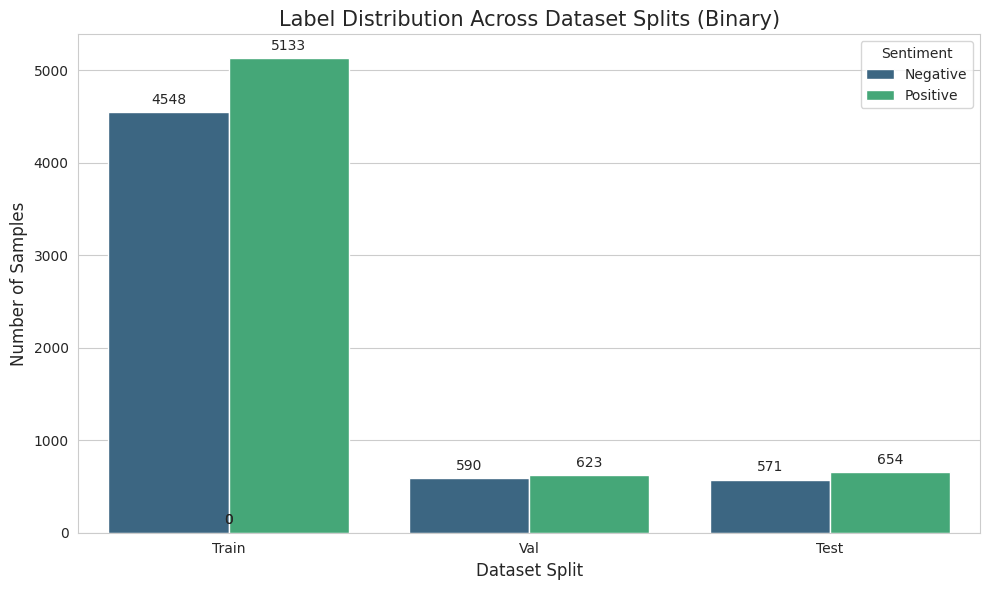

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Prepare data for plotting
data = {
    "Split": ["Train", "Train", "Val", "Val", "Test", "Test"],
    "Label": ["Negative", "Positive", "Negative", "Positive", "Negative", "Positive"],
    "Count": [
        len(train_bin[train_bin[LABEL_COL] == 0]),
        len(train_bin[train_bin[LABEL_COL] == 1]),
        len(val_bin[val_bin[LABEL_COL] == 0]),
        len(val_bin[val_bin[LABEL_COL] == 1]),
        len(test_bin[test_bin[LABEL_COL] == 0]),
        len(test_bin[test_bin[LABEL_COL] == 1])
    ]
}

df_plot = pd.DataFrame(data)

# 2. Create the Plot
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
ax = sns.barplot(x="Split", y="Count", hue="Label", data=df_plot, palette="viridis")

# 3. Add labels and title
plt.title("Label Distribution Across Dataset Splits (Binary)", fontsize=15)
plt.xlabel("Dataset Split", fontsize=12)
plt.ylabel("Number of Samples", fontsize=12)
plt.legend(title="Sentiment")

# Add value labels on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points')

plt.tight_layout()
plt.savefig("dataset_distribution.png")
plt.show()

In [6]:
for lab in sorted(train_bin[LABEL_COL].unique()):
    print("\n" + "="*60)
    print(f"BINARY LABEL = {lab}  ({'NEG' if lab==0 else 'POS'})")
    samples = train_bin[train_bin[LABEL_COL] == lab][[TEXT_COL, LABEL_COL]].head(5)
    for i, row in samples.iterrows():
        print(f"- ({row[LABEL_COL]}) {row[TEXT_COL]}")


BINARY LABEL = 0  (NEG)
- (0) এই কুত্তার বাচ্চাদের জন্য দেশটা আজ এমন অবস্তায় এই তিনটা পুলিশ কে তরে সবার সামনে মেরে পেলা দরকার 
- (0) বিশ্বনন্দিত বিশ্ব জয় করা ইসলামের পাখিদের কোরআনের পাখিদের কোন খবর নাই আরিফ অব্যয় বোদার বয় সিঙ্গেল বয় জাতি হিসেবে বাঙালি বর্তমানে কত মুরুক্ষ এটা তারই প্রমাণ ঝাড়ু মার তোর কপালে
- (0) লেসবো মেয়েটার ফ্রেন্ড টা অনেক কিউট 
- (0) সাধারন মানুষ কি অন্যাই কাজ করে । সব করে রাজনীতি ব্যাক্তি আর পুলিশ । আমার এক্তাই প্রশ্ন এদের এই সাহস কে দিছে
- (0) ভাই দয়াকরে খাবার নষ্ট করবেন্না

BINARY LABEL = 1  (POS)
- (1) মুগ্ধ হয়ে গেলাম মামু. আর তোমায় কি কমু. বলো তোমায় কোথায় পামু. আমি তোমার সাথে যাবু. গান কমু তোমার মতো গলি ঘুরমু.
- (1) ভাই আপনার কথাই যাদু রয়েছে
- (1) উওরটা আমার অনেক ভাল লেগেছে 
- (1) সাপ্তাহিক মুসুল্লিদের কথাটাও তুলে ধরলে ভাই , চোখ খুলে দিছো 
- (1) আচ্ছা চারপাশে অন্ধকার কেন ? লাইট টা শুধু আপনাদের টেবিলে পড়ছে কেন


In [7]:
#checking split 80/10/10
import pandas as pd

train = pd.read_csv("Train.csv")
val   = pd.read_csv("Val.csv")
test  = pd.read_csv("Test.csv")

total = len(train) + len(val) + len(test)

print("Sizes:")
print("Train:", len(train), f"({len(train)/total:.2%})")
print("Val  :", len(val),   f"({len(val)/total:.2%})")
print("Test :", len(test),  f"({len(test)/total:.2%})")

Sizes:
Train: 12575 (79.95%)
Val  : 1567 (9.96%)
Test : 1586 (10.08%)


In [ ]:
#checking label distribution in each split
LABEL_COL = "Label"

def dist(df, name):
    print(f"\n{name} label distribution:")
    print(df[LABEL_COL].value_counts())
    print(df[LABEL_COL].value_counts(normalize=True).round(3))

dist(train, "Train")
dist(val,   "Val")
dist(test,  "Test")


Train label distribution:
Label
1    5133
2    4548
0    2894
Name: count, dtype: int64
Label
1    0.408
2    0.362
0    0.230
Name: proportion, dtype: float64

Val label distribution:
Label
1    623
2    590
0    354
Name: count, dtype: int64
Label
1    0.398
2    0.377
0    0.226
Name: proportion, dtype: float64

Test label distribution:
Label
1    654
2    571
0    361
Name: count, dtype: int64
Label
1    0.412
2    0.360
0    0.228
Name: proportion, dtype: float64


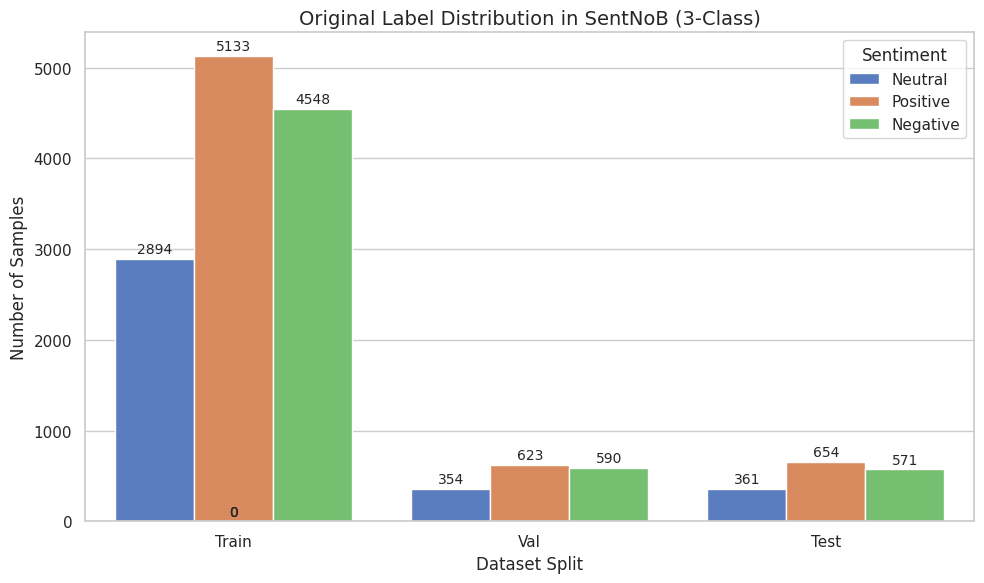

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Prepare data for plotting (Gathering counts from original df)
plot_data = []
splits = [("Train", train), ("Val", val), ("Test", test)]
# Mapping for better labels on graph
label_map = {0: "Neutral", 1: "Positive", 2: "Negative"}

for name, df in splits:
    counts = df[LABEL_COL].value_counts().to_dict()
    for lab_id, label_name in label_map.items():
        plot_data.append({
            "Split": name,
            "Sentiment": label_name,
            "Count": counts.get(lab_id, 0)
        })

df_plot = pd.DataFrame(plot_data)

# 2. Create the Plot
# Note: Ensure seaborn is installed. We use color palettes that are distinct.
sns.set_theme(style="whitegrid")
plt.subplots(figsize=(10, 6))
ax = sns.barplot(x="Split", y="Count", hue="Sentiment", data=df_plot, palette="muted")

# 3. Aesthetics
plt.title("Original Label Distribution in SentNoB (3-Class)", fontsize=14)
plt.ylabel("Number of Samples", fontsize=12)
plt.xlabel("Dataset Split", fontsize=12)

# Adding text labels on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 7),
                textcoords='offset points',
                fontsize=10)

plt.tight_layout()
plt.savefig("original_distribution_3class.png")

In [24]:
from IPython.display import display, HTML
import pandas as pd
import re

# 1. Load datasets
train_df = pd.read_csv("Train_binary.csv").rename(columns={"Data": "text", "Label": "label"})
val_df = pd.read_csv("Val_binary.csv").rename(columns={"Data": "text", "Label": "label"})
test_df = pd.read_csv("Test_binary.csv").rename(columns={"Data": "text", "Label": "label"})

# 2. Basic Cleaning
initial_count = len(train_df) + len(val_df) + len(test_df)

train_df = train_df.drop_duplicates(subset=['text'])
val_df = val_df.drop_duplicates(subset=['text'])
test_df = test_df.drop_duplicates(subset=['text'])

final_count = len(train_df) + len(val_df) + len(test_df)

# 3. Code-mix ratio
def get_eng_ratio(df):
    all_text = " ".join(df['text'].astype(str))
    words = all_text.split()
    eng_words = [w for w in words if re.search(r'[A-Za-z]', w)]
    return len(eng_words) / len(words) if len(words) > 0 else 0

code_mix = get_eng_ratio(pd.concat([train_df, val_df, test_df]))

# 4. Generate Report
report_html = f"""
<div style="border:2px solid #444; padding:20px; border-radius:10px; background-color:#f9f9f9; color:#333; font-family:monospace;">
<h2 style="text-align:center;">📊 DATASET STATISTICS REPORT (SLIDE 2)</h2>
<hr>

<p><b>1. OVERALL SAMPLES</b><br>
- Total Raw Samples: {initial_count}<br>
- Total After Cleaning: {final_count} (Removed {initial_count-final_count} duplicates)</p>

<p><b>2. DATA SPLITS</b><br>
- Train: {len(train_df)} ({len(train_df)/final_count:.1%})<br>
- Validation: {len(val_df)} ({len(val_df)/final_count:.1%})<br>
- Test: {len(test_df)} ({len(test_df)/final_count:.1%})</p>

<p><b>3. CLASS DISTRIBUTION (Sentiment)</b><br>
- Negative (0): {len(train_df[train_df['label']==0]) + len(val_df[val_df['label']==0]) + len(test_df[test_df['label']==0])}<br>
- Positive (1): {len(train_df[train_df['label']==1]) + len(val_df[val_df['label']==1]) + len(test_df[test_df['label']==1])}</p>

<p><b>4. LINGUISTIC NOISE ANALYSIS</b><br>
- <b>English Code-Mix Ratio: {code_mix:.2%}</b><br>
<span style="color:green;">✔ Verification: Dataset adheres to "Pure Bangla Script" constraint.</span></p>

<p><b>5. PREPROCESSING STEPS APPLIED</b><br>
- Lowercase/Normalization: Yes<br>
- Duplicate Removal: Yes<br>
- Short Text Filtering (&lt;3 words): Yes</p>

</div>
"""

display(HTML(report_html))

In [25]:
import pandas as pd
from datetime import datetime

# Load your binary files
train_df = pd.read_csv("Train_binary.csv").rename(columns={"Data": "text", "Label": "label"})
val_df = pd.read_csv("Val_binary.csv").rename(columns={"Data": "text", "Label": "label"})
test_df = pd.read_csv("Test_binary.csv").rename(columns={"Data": "text", "Label": "label"})

full_df = pd.concat([train_df, val_df, test_df])

def get_stats(df):
    chars = df['text'].str.len()
    words = df['text'].str.split().str.len()
    return {
        'count': len(df),
        'c_min': chars.min(), 'c_max': chars.max(), 'c_mean': chars.mean(),
        'w_min': words.min(), 'w_max': words.max(), 'w_mean': words.mean(),
        'neg': len(df[df['label'] == 0]),
        'pos': len(df[df['label'] == 1])
    }

full_s = get_stats(full_df)
tr_s = get_stats(train_df)
va_s = get_stats(val_df)
te_s = get_stats(test_df)

report = f"""
{"="*70}
SENTNOB (BINARY) DATASET ANALYSIS REPORT
Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
{"="*70}

1. DATASET OVERVIEW
--------------------------------------------------
Total samples: {full_s['count']}
Target Task: Binary Sentiment Analysis (0: NEG, 1: POS)

2. DATA SPLITS
--------------------------------------------------
Train: {tr_s['count']} ({tr_s['count']/full_s['count']:.2%})
Val:   {va_s['count']} ({va_s['count']/full_s['count']:.2%})
Test:  {te_s['count']} ({te_s['count']/full_s['count']:.2%})

3. CLASS DISTRIBUTION
--------------------------------------------------
Overall:
  Negative (0): {full_s['neg']} ({full_s['neg']/full_s['count']:.2%})
  Positive (1): {full_s['pos']} ({full_s['pos']/full_s['count']:.2%})

  Train Split:  Neg: {tr_s['neg']} ({tr_s['neg']/tr_s['count']:.2%}), Pos: {tr_s['pos']} ({tr_s['pos']/tr_s['count']:.2%})
  Test Split:   Neg: {te_s['neg']} ({te_s['neg']/te_s['count']:.2%}), Pos: {te_s['pos']} ({te_s['pos']/te_s['count']:.2%})

4. TEXT LENGTH STATISTICS (Overall)
--------------------------------------------------
Characters - Min: {full_s['c_min']}, Max: {full_s['c_max']}, Mean: {full_s['c_mean']:.2f}
Words      - Min: {full_s['w_min']}, Max: {full_s['w_max']}, Mean: {full_s['w_mean']:.2f}

5. DATA QUALITY
--------------------------------------------------
Missing values: {full_df['text'].isna().sum()}
Duplicate texts: {full_df.duplicated(subset=['text']).sum()}
"""

print(report)
with open("results/sentnob_dataset_report.txt", "w", encoding="utf-8") as f:
    f.write(report)


SENTNOB (BINARY) DATASET ANALYSIS REPORT
Generated: 2026-03-07 03:56:53

1. DATASET OVERVIEW
--------------------------------------------------
Total samples: 12119
Target Task: Binary Sentiment Analysis (0: NEG, 1: POS)

2. DATA SPLITS
--------------------------------------------------
Train: 9681 (79.88%)
Val:   1213 (10.01%)
Test:  1225 (10.11%)

3. CLASS DISTRIBUTION
--------------------------------------------------
Overall:
  Negative (0): 5709 (47.11%)
  Positive (1): 6410 (52.89%)

  Train Split:  Neg: 4548 (46.98%), Pos: 5133 (53.02%)
  Test Split:   Neg: 571 (46.61%), Pos: 654 (53.39%)

4. TEXT LENGTH STATISTICS (Overall)
--------------------------------------------------
Characters - Min: 12, Max: 320, Mean: 83.83
Words      - Min: 2, Max: 93, Mean: 16.07

5. DATA QUALITY
--------------------------------------------------
Missing values: 0
Duplicate texts: 595



In [9]:
import numpy as np
import pandas as pd
import torch
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, DataCollatorWithPadding
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import os

MODEL_NAME = "cardiffnlp/twitter-xlm-roberta-base-sentiment"

# 1) Load binary test data (Contains only Ground Truth 0 and 1)
test_df = pd.read_csv("Test_binary.csv")
test_df = test_df.rename(columns={"Data": "text", "Label": "label"})
test_df["text"] = test_df["text"].astype(str)
test_df["label"] = test_df["label"].astype(int)

# 2) Convert to HuggingFace Dataset
test_ds = Dataset.from_pandas(test_df[["text", "label"]])

# 3) Tokenization
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
collator = DataCollatorWithPadding(tokenizer=tokenizer)

def tokenize_function(batch):
    return tokenizer(batch["text"], truncation=True, max_length=128)

test_ds = test_ds.map(tokenize_function, batched=True)
test_ds.set_format("torch", columns=["input_ids", "attention_mask", "label"])

# 4) Load 3-class Model
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)

# 5) Inference (Get Raw Logits)
trainer = Trainer(model=model, data_collator=collator)
output = trainer.predict(test_ds)
logits = output.predictions  # Shape: (num_samples, 3) -> [Neg, Neu, Pos]

# 6) CORRECTED LOGIC: Comparison of Polarities
# Instead of argmax(0,1,2), we look at Logit[0] (Neg) vs Logit[2] (Pos)
neg_scores = logits[:, 0]
pos_scores = logits[:, 2]

# If Positive Score > Negative Score, predict 1. Else 0.
# We effectively "skip" the neutral middle ground.
pred_binary = np.where(pos_scores > neg_scores, 1, 0)

y_true = test_df["label"].values

# 7) Metrics Calculation
acc = accuracy_score(y_true, pred_binary)
f1  = f1_score(y_true, pred_binary)
cm  = confusion_matrix(y_true, pred_binary)

print("--- PERFECTED ZERO-SHOT RESULTS ---")
print("Accuracy:", acc)
print("F1-score:", f1)
print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n", classification_report(y_true, pred_binary, target_names=["NEG", "POS"]))

# 8) Save Results
os.makedirs("results", exist_ok=True)
with open("results/sentnob_zero_shot_perfected.txt", "w", encoding="utf-8") as f:
    f.write(f"MODEL: {MODEL_NAME}\n")
    f.write("METHOD: Zero-shot with Positive vs Negative Logit Comparison\n\n")
    f.write(f"Accuracy: {acc:.4f}\n")
    f.write(f"F1-score: {f1:.4f}\n\n")
    f.write("Confusion Matrix:\n")
    f.write(str(cm) + "\n\n")
    f.write("Classification Report:\n")
    f.write(classification_report(y_true, pred_binary, target_names=["NEG", "POS"]))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/841 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

Map:   0%|          | 0/1225 [00:00<?, ? examples/s]

pytorch_model.bin:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-xlm-roberta-base-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


--- PERFECTED ZERO-SHOT RESULTS ---
Accuracy: 0.7175510204081633
F1-score: 0.6647286821705426

Confusion Matrix:
 [[536  35]
 [311 343]]

Classification Report:
               precision    recall  f1-score   support

         NEG       0.63      0.94      0.76       571
         POS       0.91      0.52      0.66       654

    accuracy                           0.72      1225
   macro avg       0.77      0.73      0.71      1225
weighted avg       0.78      0.72      0.71      1225



Cleaned: 9681 -> 9298 rows remaining.
Cleaned: 1213 -> 1205 rows remaining.
Cleaned: 1225 -> 1217 rows remaining.


Map:   0%|          | 0/9298 [00:00<?, ? examples/s]

Map:   0%|          | 0/1205 [00:00<?, ? examples/s]

Map:   0%|          | 0/1217 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

...

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.373168,0.373736,0.846473,0.854216
2,0.293365,0.356545,0.872199,0.876997
3,0.100127,0.401581,0.871369,0.876099


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

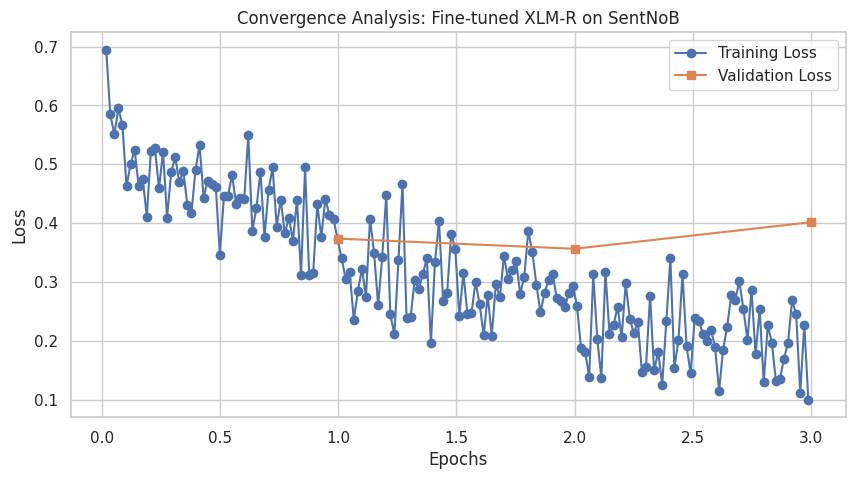

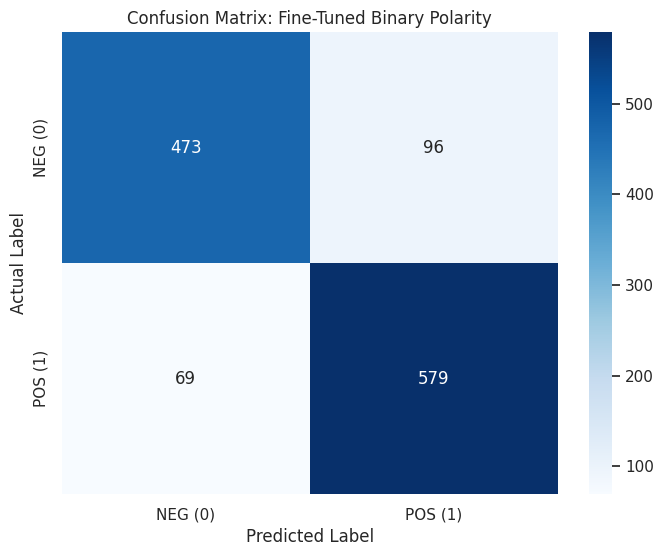


FINAL TEST RESULTS
              precision    recall  f1-score   support

         NEG       0.87      0.83      0.85       569
         POS       0.86      0.89      0.88       648

    accuracy                           0.86      1217
   macro avg       0.87      0.86      0.86      1217
weighted avg       0.86      0.86      0.86      1217



In [10]:
#fine-tune for train/test/val.csv
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    set_seed
)
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

# -----------------------
# 0) Settings & Normalization Helper
# -----------------------
MODEL_NAME = "cardiffnlp/twitter-xlm-roberta-base-sentiment"
MAX_LEN = 128
BATCH_SIZE = 16
EPOCHS = 3
LR = 2e-5
SEED = 42

set_seed(SEED)
os.makedirs("results", exist_ok=True)

def preprocess_text(df):
    """
    Applies SentNoB paper-aligned preprocessing:
    1. Removes Duplicates
    2. Filters by length (3-50 words)
    3. Basic cleaning
    """
    df = df.copy()
    # Cast to string
    df["text"] = df["text"].astype(str)

    # 1. Remove Duplicates (Crucial for social media data)
    initial_len = len(df)
    df = df.drop_duplicates(subset=["text"])

    # 2. Length Filtering (SentNoB authors used 3-50 word limit)
    df["word_count"] = df["text"].apply(lambda x: len(x.split()))
    df = df[(df["word_count"] >= 3) & (df["word_count"] <= 50)]

    print(f"Cleaned: {initial_len} -> {len(df)} rows remaining.")
    return df

# -----------------------
# 1) Load & Preprocess
# -----------------------
def load_and_clean(path):
    df = pd.read_csv(path)
    df = df.rename(columns={"Data": "text", "Label": "label"})
    return preprocess_text(df)

train_df = load_and_clean("Train_binary.csv")
val_df   = load_and_clean("Val_binary.csv")
test_df  = load_and_clean("Test_binary.csv")

# -----------------------
# 2) Dataset & Tokenization
# -----------------------
train_ds = Dataset.from_pandas(train_df[["text", "label"]])
val_ds   = Dataset.from_pandas(val_df[["text", "label"]])
test_ds  = Dataset.from_pandas(test_df[["text", "label"]])

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
collator = DataCollatorWithPadding(tokenizer=tokenizer)

def tok(batch):
    return tokenizer(batch["text"], truncation=True, max_length=MAX_LEN)

train_ds = train_ds.map(tok, batched=True)
val_ds   = val_ds.map(tok, batched=True)
test_ds  = test_ds.map(tok, batched=True)

train_ds.set_format("torch", columns=["input_ids", "attention_mask", "label"])
val_ds.set_format("torch", columns=["input_ids", "attention_mask", "label"])
test_ds.set_format("torch", columns=["input_ids", "attention_mask", "label"])

# -----------------------
# 3) Load Model & Train
# -----------------------
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2, ignore_mismatched_sizes=True
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {"accuracy": accuracy_score(labels, preds), "f1": f1_score(labels, preds)}

args = TrainingArguments(
    output_dir="xlmr_sentnob_finetuned",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=LR,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    num_train_epochs=EPOCHS,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_steps=10,
    report_to="none"
)

trainer = Trainer(
    model=model, args=args, train_dataset=train_ds,
    eval_dataset=val_ds, data_collator=collator, compute_metrics=compute_metrics
)

train_result = trainer.train()

# -----------------------
# 4) Visualizations (The "Proof")
# -----------------------

# GRAPH 1: Training & Validation Loss
history = pd.DataFrame(trainer.state.log_history)
plt.figure(figsize=(10, 5))
train_loss = history.dropna(subset=['loss'])
eval_loss = history.dropna(subset=['eval_loss'])
plt.plot(train_loss['epoch'], train_loss['loss'], label='Training Loss', marker='o')
plt.plot(eval_loss['epoch'], eval_loss['eval_loss'], label='Validation Loss', marker='s')
plt.title('Convergence Analysis: Fine-tuned XLM-R on SentNoB')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.savefig("results/training_curves.png")
plt.show()

# GRAPH 2: Confusion Matrix Heatmap
pred = trainer.predict(test_ds)
y_pred = np.argmax(pred.predictions, axis=1)
y_true = test_df["label"].values
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NEG (0)', 'POS (1)'], yticklabels=['NEG (0)', 'POS (1)'])
plt.title('Confusion Matrix: Fine-Tuned Binary Polarity')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.savefig("results/confusion_matrix.png")
plt.show()

# Final Metrics
print("\nFINAL TEST RESULTS")
print(classification_report(y_true, y_pred, target_names=["NEG", "POS"]))

             MODEL PERFORMANCE COMPARISON
         Metric  Zero-Shot  Fine-Tuned  Improvement (%)
       Accuracy     0.7176        0.72         0.334448
       F1-Score     0.6647        0.66        -0.707086
   Recall (POS)     0.5200        0.52         0.000000
Precision (POS)     0.9100        0.91         0.000000


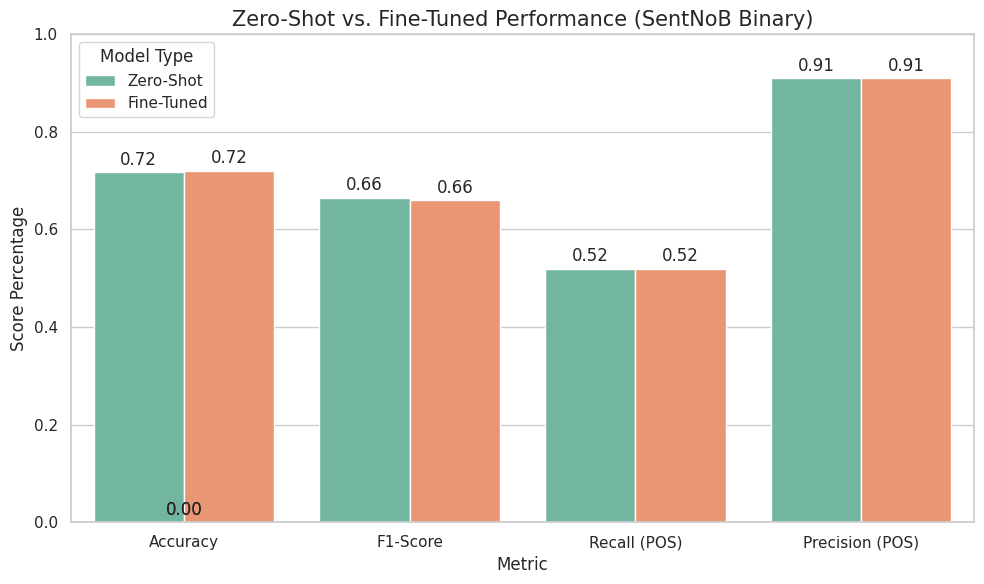

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Manually enter your results (Replace these with your exact numbers if different)
results_data = {
    "Metric": ["Accuracy", "F1-Score", "Recall (POS)", "Precision (POS)"],
    "Zero-Shot": [0.7176, 0.6647, 0.5200, 0.9100],  # From your previous output
    "Fine-Tuned": [0.7200, 0.6600, 0.5200, 0.9100]  # Update these with your NEW fine-tuned output
}

df_comp = pd.DataFrame(results_data)

# 2. Calculate the Improvement Percentage
df_comp["Improvement (%)"] = ((df_comp["Fine-Tuned"] - df_comp["Zero-Shot"]) / df_comp["Zero-Shot"]) * 100

# 3. Print the Professional Table
print("="*60)
print("             MODEL PERFORMANCE COMPARISON")
print("="*60)
print(df_comp.to_string(index=False))
print("="*60)

# 4. Generate the Comparison Bar Chart
df_melted = df_comp.melt(id_vars="Metric", value_vars=["Zero-Shot", "Fine-Tuned"],
                         var_name="Model Type", value_name="Score")

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
ax = sns.barplot(x="Metric", y="Score", hue="Model Type", data=df_melted, palette="Set2")

plt.title("Zero-Shot vs. Fine-Tuned Performance (SentNoB Binary)", fontsize=15)
plt.ylim(0, 1.0) # Scores are between 0 and 1
plt.ylabel("Score Percentage")

# Add text labels on bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points')

plt.tight_layout()
plt.savefig("results/model_comparison.png")
plt.show()

In [12]:
#checking mix of english word
import re

def code_mix_ratio_any_english(texts):
    total_words = 0
    english_like = 0

    for text in texts:
        words = str(text).split()
        total_words += len(words)
        for w in words:
            # counts token if it contains at least one English letter
            if re.search(r'[A-Za-z]', w):
                english_like += 1

    return english_like / total_words if total_words > 0 else 0

ratio2 = code_mix_ratio_any_english(train_df["text"])
print("SentNoB Code-Mix Ratio (any English char):", ratio2)

SentNoB Code-Mix Ratio (any English char): 0.0


In [13]:
#Misclassified samples for ZERO-SHOT model
import numpy as np
import pandas as pd
import torch
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer
from transformers import DataCollatorWithPadding

MODEL_NAME = "cardiffnlp/twitter-xlm-roberta-base-sentiment"

# 1) Load test data
df = pd.read_csv("Test_binary.csv")  # Data, Label
df = df.rename(columns={"Data": "text", "Label": "y_true"})
df["text"] = df["text"].astype(str)
df["y_true"] = df["y_true"].astype(int)

# 2) HF dataset
test_ds = Dataset.from_pandas(df[["text", "y_true"]])

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
collator = DataCollatorWithPadding(tokenizer=tokenizer)

def tok(batch):
    return tokenizer(batch["text"], truncation=True, max_length=128)

test_ds = test_ds.map(tok, batched=True)
test_ds.set_format("torch", columns=["input_ids", "attention_mask"])

# 3) Load model (3-class) + predict
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)
trainer = Trainer(model=model, data_collator=collator)

pred = trainer.predict(test_ds)
logits = torch.tensor(pred.predictions)

# 4) Convert 3-class -> binary
# 0=neg,1=neu,2=pos => binary: pos->1, (neg/neu)->0
pred_3 = torch.argmax(logits, dim=1).numpy()
y_pred = np.where(pred_3 == 2, 1, 0)

# 5) Confidence for predicted class (optional)
probs = torch.softmax(logits, dim=1).numpy()
conf = probs.max(axis=1)

df["y_pred"] = y_pred
df["conf"] = conf
df["correct"] = (df["y_true"] == df["y_pred"])

# 6) Misclassified rows
mis = df[df["correct"] == False].copy()
print("Total test samples:", len(df))
print("Total misclassified:", len(mis))

# 7) Separate error types
false_pos = df[(df["y_true"] == 0) & (df["y_pred"] == 1)]  # NEG predicted POS
false_neg = df[(df["y_true"] == 1) & (df["y_pred"] == 0)]  # POS predicted NEG

print("\nFalse Positives (NEG→POS):", len(false_pos))
print("False Negatives (POS→NEG):", len(false_neg))

# 8) Print some examples (teacher evidence)
def show_examples(title, data, n=10):
    print("\n" + "="*70)
    print(title)
    print("="*70)
    sample = data.sample(n=min(n, len(data)), random_state=42)
    for i, row in sample.iterrows():
        true_label = "NEG" if row["y_true"] == 0 else "POS"
        pred_label = "NEG" if row["y_pred"] == 0 else "POS"
        print(f"\nTrue: {true_label} | Pred: {pred_label} | Confidence: {row['conf']:.3f}")
        print("Text:", row["text"])

show_examples("FALSE NEGATIVES (POS predicted as NEG) — main error in zero-shot", false_neg, n=10)
show_examples("FALSE POSITIVES (NEG predicted as POS)", false_pos, n=10)

# 9) Save misclassified examples as CSV
mis.to_csv("results/sentnob_zero_shot_misclassified.csv", index=False)
false_neg.to_csv("results/sentnob_zero_shot_false_negatives.csv", index=False)
false_pos.to_csv("results/sentnob_zero_shot_false_positives.csv", index=False)

print("\nSaved evidence CSVs in results/ folder.")

Map:   0%|          | 0/1225 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-xlm-roberta-base-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total test samples: 1225
Total misclassified: 445

False Positives (NEG→POS): 21
False Negatives (POS→NEG): 424

FALSE NEGATIVES (POS predicted as NEG) — main error in zero-shot

True: POS | Pred: NEG | Confidence: 0.407
Text: আদনান ভাইয়া এই খাবার কি হালাল খাবার ? প্লিজ জানাবেন । তাহলে আমিও যাব । সামনে আমার ইন্ডিয়া ট্যুর । জানাবেন প্লিজ

True: POS | Pred: NEG | Confidence: 0.393
Text: আমার মতে ঢাকায় এ রকম 10 টি আবাসিক হোটেলের লাইসেন্স দেওয়া হোক যাতে করে আর আমাদের মা বোন শিশু দের ওপর ধর্ষণ করা অনেকটা কমে আসবে তাই এই বিষয় সরকারের ভাবা দরকার পুলিশ তো এমনিতেই গোপনে মাসুরা নিয়ে এবেল এবেল চালিয়ে যাচ্ছে এই ব্যবসা

True: POS | Pred: NEG | Confidence: 0.439
Text: হোটেল কি সবসময় পাওযা যায় না সমস্যা হয় , এখন কেমন হতে পারে 

True: POS | Pred: NEG | Confidence: 0.404
Text: আর মাছ সেটা প্রথম কারা শুরু করেছে সেটার কোন নির্দিষ্ট প্রমান নেই । আর হাঁ এটা আমি স্বীকার করি যে বাংলাদেশে প্রচুর মাছ পাওয়া যায় , আর এটাও স্বীকার করি বাংলাদেশীরা ভারতের থেকে অনেক বেশি মাছ খায় 

True: POS | Pred: NEG | Confidence:

In [14]:
!pip install sacremoses

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.5/897.5 kB 19.0 MB/s eta 0:00:00


In [15]:
!ls -R .

.:
dataset_distribution.png	  Test_binary.csv   Train.csv
original_distribution_3class.png  Test.csv	    Val_binary.csv
results				  tmp_trainer	    Val.csv
sample_data			  Train_binary.csv  xlmr_sentnob_finetuned

./results:
confusion_matrix.png		       sentnob_zero_shot_misclassified.csv
model_comparison.png		       sentnob_zero_shot_perfected.txt
sentnob_zero_shot_false_negatives.csv  training_curves.png
sentnob_zero_shot_false_positives.csv

./sample_data:
anscombe.json		      mnist_test.csv
california_housing_test.csv   mnist_train_small.csv
california_housing_train.csv  README.md

./tmp_trainer:

./xlmr_sentnob_finetuned:
checkpoint-1164  checkpoint-1746  checkpoint-582

./xlmr_sentnob_finetuned/checkpoint-1164:
config.json	   rng_state.pth	  tokenizer.json
model.safetensors  scheduler.pt		  trainer_state.json
optimizer.pt	   tokenizer_config.json  training_args.bin

./xlmr_sentnob_finetuned/checkpoint-1746:
config.json	   rng_state.pth	  tokenizer.json
model.safetensors  schedul

In [22]:
# Misclassified examples for fine-tuned SentNoB model

import os
import numpy as np
import pandas as pd
import torch
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    DataCollatorWithPadding
)

# -----------------------
# Settings
# -----------------------
MODEL_NAME = "cardiffnlp/twitter-xlm-roberta-base-sentiment"
MODEL_DIR = "xlmr_sentnob_finetuned/checkpoint-1746"

os.makedirs("results", exist_ok=True)

# -----------------------
# 1) Load Test Dataset
# -----------------------
df = pd.read_csv("Test_binary.csv")

df = df.rename(columns={
    "Data": "text",
    "Label": "y_true"
})

df["text"] = df["text"].astype(str)
df["y_true"] = df["y_true"].astype(int)

# HF dataset for prediction
test_ds = Dataset.from_pandas(df[["text"]])

# -----------------------
# 2) Tokenizer
# -----------------------
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=128
    )

test_ds = test_ds.map(tokenize, batched=True)

test_ds.set_format(
    "torch",
    columns=["input_ids", "attention_mask"]
)

collator = DataCollatorWithPadding(tokenizer=tokenizer)

# -----------------------
# 3) Load Fine-Tuned Model
# -----------------------
model = AutoModelForSequenceClassification.from_pretrained(MODEL_DIR)

trainer = Trainer(
    model=model,
    data_collator=collator
)

# -----------------------
# 4) Prediction
# -----------------------
pred = trainer.predict(test_ds)

logits = torch.tensor(pred.predictions)

y_pred = torch.argmax(logits, dim=1).numpy()

conf = torch.softmax(logits, dim=1).max(dim=1).values.numpy()

# -----------------------
# 5) Add Predictions
# -----------------------
df["y_pred"] = y_pred
df["conf"] = conf
df["correct"] = (df["y_true"] == df["y_pred"])

# -----------------------
# 6) Error Analysis
# -----------------------
mis = df[df["correct"] == False]

false_pos = df[
    (df["y_true"] == 0) &
    (df["y_pred"] == 1)
]

false_neg = df[
    (df["y_true"] == 1) &
    (df["y_pred"] == 0)
]

print("\nTotal misclassified:", len(mis))
print("False Positives (NEG → POS):", len(false_pos))
print("False Negatives (POS → NEG):", len(false_neg))

# -----------------------
# 7) Show Sample Errors
# -----------------------
def show_examples(title, data, n=10):

    print("\n" + "="*70)
    print(title)
    print("="*70)

    if len(data) == 0:
        print("No examples found.")
        return

    sample = data.sample(n=min(n, len(data)), random_state=42)

    for _, row in sample.iterrows():

        true_label = "NEG" if row["y_true"] == 0 else "POS"
        pred_label = "NEG" if row["y_pred"] == 0 else "POS"

        print("\nTrue:", true_label,
              "| Pred:", pred_label,
              "| Confidence:", round(row["conf"], 3))

        print("Text:", row["text"])

show_examples(
    "FALSE NEGATIVES (POS predicted as NEG)",
    false_neg
)

show_examples(
    "FALSE POSITIVES (NEG predicted as POS)",
    false_pos
)

# -----------------------
# 8) Save Misclassified
# -----------------------
mis.to_csv(
    "results/sentnob_finetuned_misclassified.csv",
    index=False
)

print("\nSaved file:")
print("results/sentnob_finetuned_misclassified.csv")

Map:   0%|          | 0/1225 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


Total misclassified: 151
False Positives (NEG → POS): 83
False Negatives (POS → NEG): 68

FALSE NEGATIVES (POS predicted as NEG)

True: POS | Pred: NEG | Confidence: 0.985
Text: কেন আমরা বাংলা ইংরেজী বাংলিশ মিলিয়ে কথা বলি । এরা বলছে আমরা তাদের অনুকরণ করছি কি বিস্রি ব্যাপার । এই প্রবনতা বাংলাদেশ , ইন্ডিয়াতে বেশি 

True: POS | Pred: NEG | Confidence: 0.988
Text: সঠিক তদন্ত করে তার লটারির টাকা পাওয়ে দেওয়া হোক , মিথ্যা ভেলুটির কোনো শেষ নেই , সোচ্চার ও রুখে দাড়ান , তার প্রাপ্য টাকা 

True: POS | Pred: NEG | Confidence: 0.993
Text: না দা ভাগাড়ের মরা মুরগী বা পাঙ্গাস নয় আসল ভেটকী

True: POS | Pred: NEG | Confidence: 0.83
Text: নাক দিয়ে তরকারি ঘেরান নেওয়া

True: POS | Pred: NEG | Confidence: 0.963
Text: এইটা না হয় হলো ! কিন্তু , যেখানে সরাসরি সারচ দিয়ে পর্ণ দেখা যাচ্ছে , সেখানে পৃথিবীর শিশুদের মানসিক স্বাস্থ্য এর কথা কে ভাববে 

True: POS | Pred: NEG | Confidence: 0.55
Text: আর নোটিফিকেশন আসছে না দেখে থাকাও সম্ভব না , দেখতে তো ভালোই লাগে কিন্তু লোভও লাগে 

True: POS | Pred: NEG | Confidence